In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayushv322/national-family-health-survey/national_family_health_survey.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

print('ok')

ok


In [3]:
df=pd.read_csv('/kaggle/input/datasets/ayushv322/national-family-health-survey/national_family_health_survey.csv')
df.head()

,Unnamed: 0,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
3,3,Srikakulam,Andhra Pradesh,874,780,100,60.0,20.7,1140,1163,...,14.4,5.5,22.9,1.0,0.2,3.8,7.1,21.3,0.6,28.3
4,4,Vizianagaram,Andhra Pradesh,902,853,134,56.0,20.6,1114,898,...,14.8,6.4,25.1,4.9,0.6,7.3,11.4,21.5,0.8,32.3


In [4]:
df.shape

(706, 110)

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'District Names',
 'State/UT',
 'Number of Households surveyed',
 'Number of Women age 15-49 years interviewed',
 'Number of Men age 15-54 years interviewed',
 'Female population age 6 years and above who ever attended school (%)',
 'Population below age 15 years (%)',
 ' Sex ratio of the total population (females per 1,000 males)',
 'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
 'Children under age 5 years whose birth was registered with the civil authority (%)',
 'Deaths in the last 3 years registered with the civil authority (%)',
 'Population living in households with electricity (%)',
 'Population living in households with an improved drinking-water source1 (%)',
 'Population living in households that use an improved sanitation facility2 (%)',
 'Households using clean fuel for cooking3 (%)',
 'Households using iodized salt (%)',
 'Households with any usual member covered under a health insurance/financing scheme (%)',
 'Ch

In [6]:
for col in df.columns:
    print(f'{col:60s} → {df[col].dropna().unique()[:4]}')

Unnamed: 0                                                   → [0 1 2 3]
District Names                                               → ['Nicobars' 'North & Middle Andaman ' 'South Andaman ' 'Srikakulam ']
State/UT                                                     → ['Andaman & Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh' 'Assam']
Number of Households surveyed                                → [882 874 868 902]
Number of Women age 15-49 years interviewed                  → [764 789 844 780]
Number of Men age 15-54 years interviewed                    → [125 108 134 100]
Female population age 6 years and above who ever attended school (%) → [78.  82.7 84.7 60. ]
Population below age 15 years (%)                            → [23.  19.8 21.  20.7]
 Sex ratio of the total population (females per 1,000 males) → [ 973  950  967 1140]
Sex ratio at birth for children born in the last five years (females per 1,000 males) → ['927 ' '844 ' '935 ' '1163 ']
Children under age 5 years whos

In [7]:
# Run this to find columns by keyword — change keyword as needed
def find_cols(keyword):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    for m in matches:
        print(f'  {m}')
    if not matches:
        print(f'  No columns found for "{keyword}"')

find_cols('stunt')
find_cols('wast')
find_cols('underweight')
find_cols('state')
find_cols('district')
# find_cols('wealth')
find_cols('literate')
find_cols('school')
find_cols('sanit')
# find_cols('toilet')
find_cols('water')

  Children under 5 years who are stunted (height-for-age)18 (%)
  Children under 5 years who are wasted (weight-for-height)18 (%)
  Children under 5 years who are severely wasted (weight-for-height)19 (%)
  Children under 5 years who are underweight (weight-for-age)18 (%)
  State/UT
  District Names
  Women (age 15-49) who are literate4 (%)
  Female population age 6 years and above who ever attended school (%)
  Children age 5 years who attended pre-primary school during the school year 2019-20 (%)
  Women (age 15-49)  with 10 or more years of schooling (%)
  Population living in households that use an improved sanitation facility2 (%)
  Population living in households with an improved drinking-water source1 (%)


In [8]:
# ── UPDATED to match your dataset EXACTLY ──────────────

TARGET = 'Children under 5 years who are stunted (height-for-age)18 (%)'

FEATURES = {
    'wealth':      'Population living in households with electricity (%)',
    'water':       'Population living in households with an improved drinking-water source1 (%)',
    'sanitation':  'Population living in households that use an improved sanitation facility2 (%)',
    'cooking':     'Households using clean fuel for cooking3 (%)',
    'mother_edu':  'Women (age 15-49)  with 10 or more years of schooling (%)',
    'antenatal':   'Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)',
    'breastfed':   'Children under age 6 months exclusively breastfed16 (%)',
    'anaemia_w':   'All women age 15-49 years who are anaemic22 (%)',
    'underweight_w': 'Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)',
}
# Check which exist
print('Checking columns...')
for k, v in FEATURES.items():
    exists = v in df.columns
    print(f'  {"✅" if exists else "❌"}  {k}: {v}')
print(f'\n  Target: {"✅" if TARGET in df.columns else "❌"}  {TARGET}')

Checking columns...
  ✅  wealth: Population living in households with electricity (%)
  ✅  water: Population living in households with an improved drinking-water source1 (%)
  ✅  sanitation: Population living in households that use an improved sanitation facility2 (%)
  ✅  cooking: Households using clean fuel for cooking3 (%)
  ✅  mother_edu: Women (age 15-49)  with 10 or more years of schooling (%)
  ✅  antenatal: Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)
  ✅  breastfed: Children under age 6 months exclusively breastfed16 (%)
  ✅  anaemia_w: All women age 15-49 years who are anaemic22 (%)
  ✅  underweight_w: Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)

  Target: ✅  Children under 5 years who are stunted (height-for-age)18 (%)


In [9]:
# Keep only columns that exist
valid_features = {k: v for k, v in FEATURES.items() if v in df.columns}
use_cols = list(valid_features.values())

if TARGET not in df.columns:
    print(f'❌ Target column "{TARGET}" not found — update it in Cell 6')
else:
    df_model = df[use_cols + [TARGET]].copy()
    
    # Rename to short names for easier reading
    rename_map = {v: k for k, v in valid_features.items()}
    df_model = df_model.rename(columns=rename_map)
    
    # Convert all to numeric — some columns may have '%' signs or strings
    for col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    
    # Fill missing with median
    df_model = df_model.fillna(df_model.median())
    
    # Drop rows where target is missing
    df_model = df_model.dropna(subset=['stunted' if 'stunted' in df_model.columns else TARGET])
    
    print(f'Clean dataset: {df_model.shape}')
    print(f'\nMissing values: {df_model.isnull().sum().sum()}')
    df_model.describe()

Clean dataset: (706, 10)

Missing values: 0


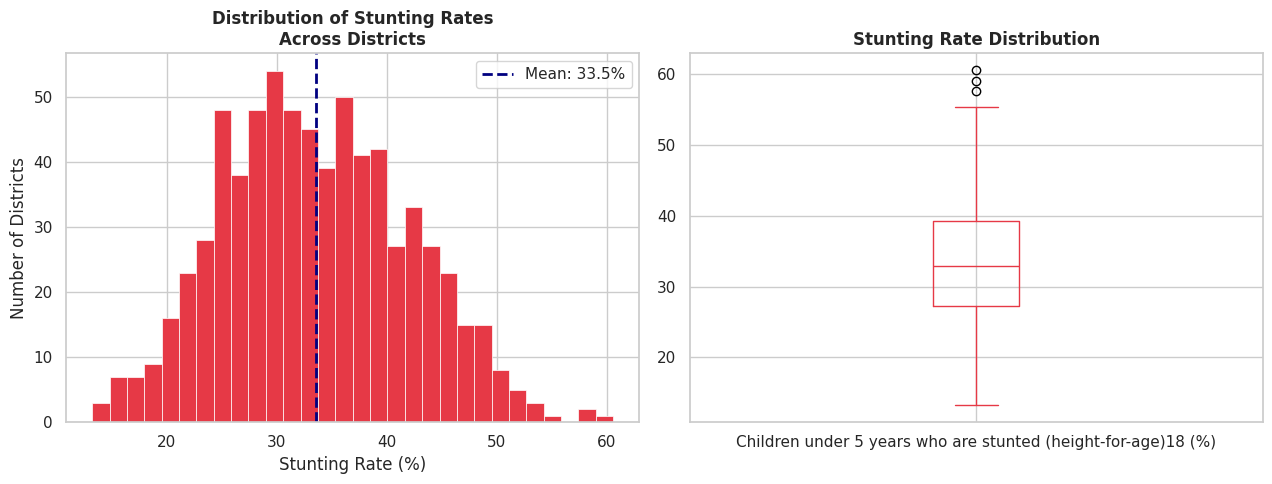

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of stunting rates across districts
axes[0].hist(df_model[TARGET], bins=30, color='#e63946', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_model[TARGET].mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Mean: {df_model[TARGET].mean():.1f}%')
axes[0].set_xlabel('Stunting Rate (%)')
axes[0].set_ylabel('Number of Districts')
axes[0].set_title('Distribution of Stunting Rates\nAcross Districts', fontweight='bold')
axes[0].legend()

# Right: box plot comparing rural vs urban if available
if 'State' in df.columns:
    top10 = df.nlargest(10, TARGET)[['State', TARGET]] if 'State' in df.columns else None
    if top10 is not None:
        axes[1].barh(top10['State'], top10[TARGET], color='#e63946', edgecolor='white')
        axes[1].set_xlabel('Stunting Rate (%)')
        axes[1].set_title('Top 10 States by Stunting Rate', fontweight='bold')
else:
    df_model[TARGET].plot(kind='box', ax=axes[1], color='#e63946')
    axes[1].set_title('Stunting Rate Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_distribution.png', dpi=150)
plt.show()

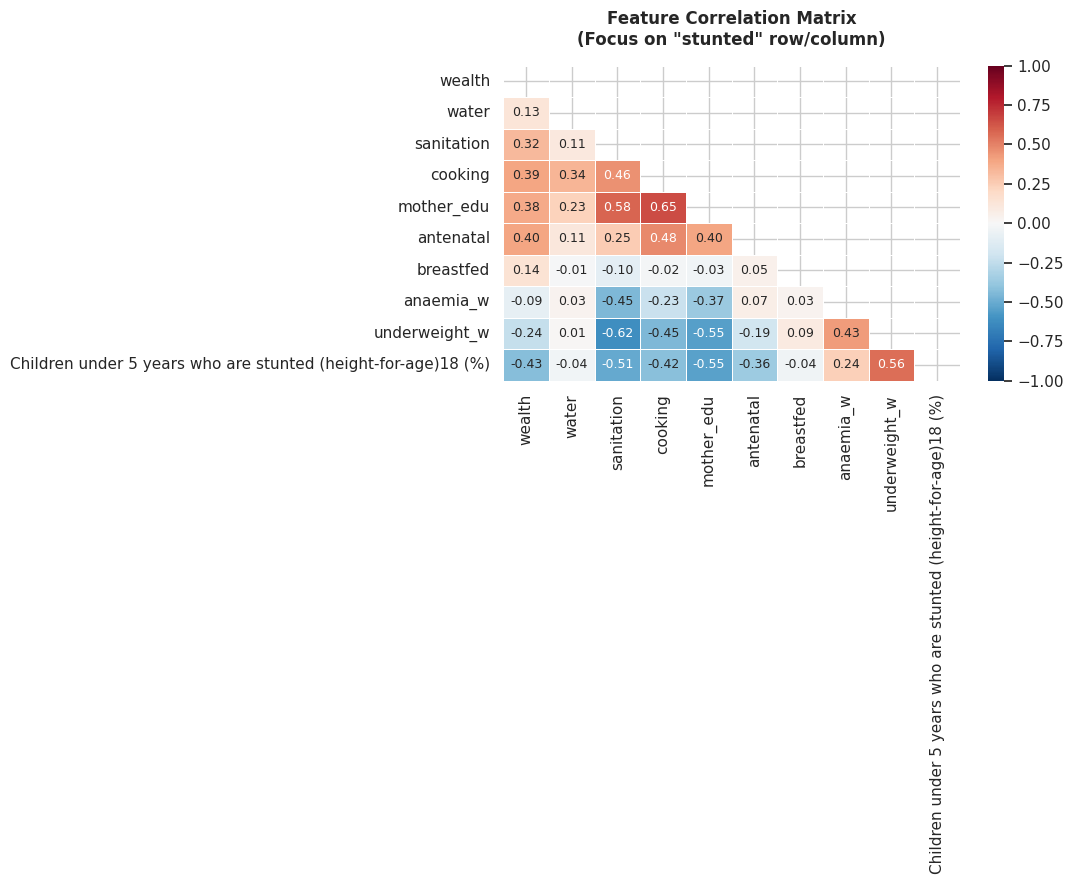


Correlation with stunting rate:
mother_edu      -0.546351
sanitation      -0.509634
wealth          -0.429084
cooking         -0.420070
antenatal       -0.360566
breastfed       -0.044524
water           -0.037307
anaemia_w        0.239868
underweight_w    0.558321
Name: Children under 5 years who are stunted (height-for-age)18 (%), dtype: float64


In [11]:
# Shows which features are most correlated with stunting
# Dark red = strong positive correlation, dark blue = strong negative

corr = df_model.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (it's a mirror)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix\n(Focus on "stunted" row/column)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print just the correlation with the target — sorted
print('\nCorrelation with stunting rate:')
print(corr[TARGET].drop(TARGET).sort_values())

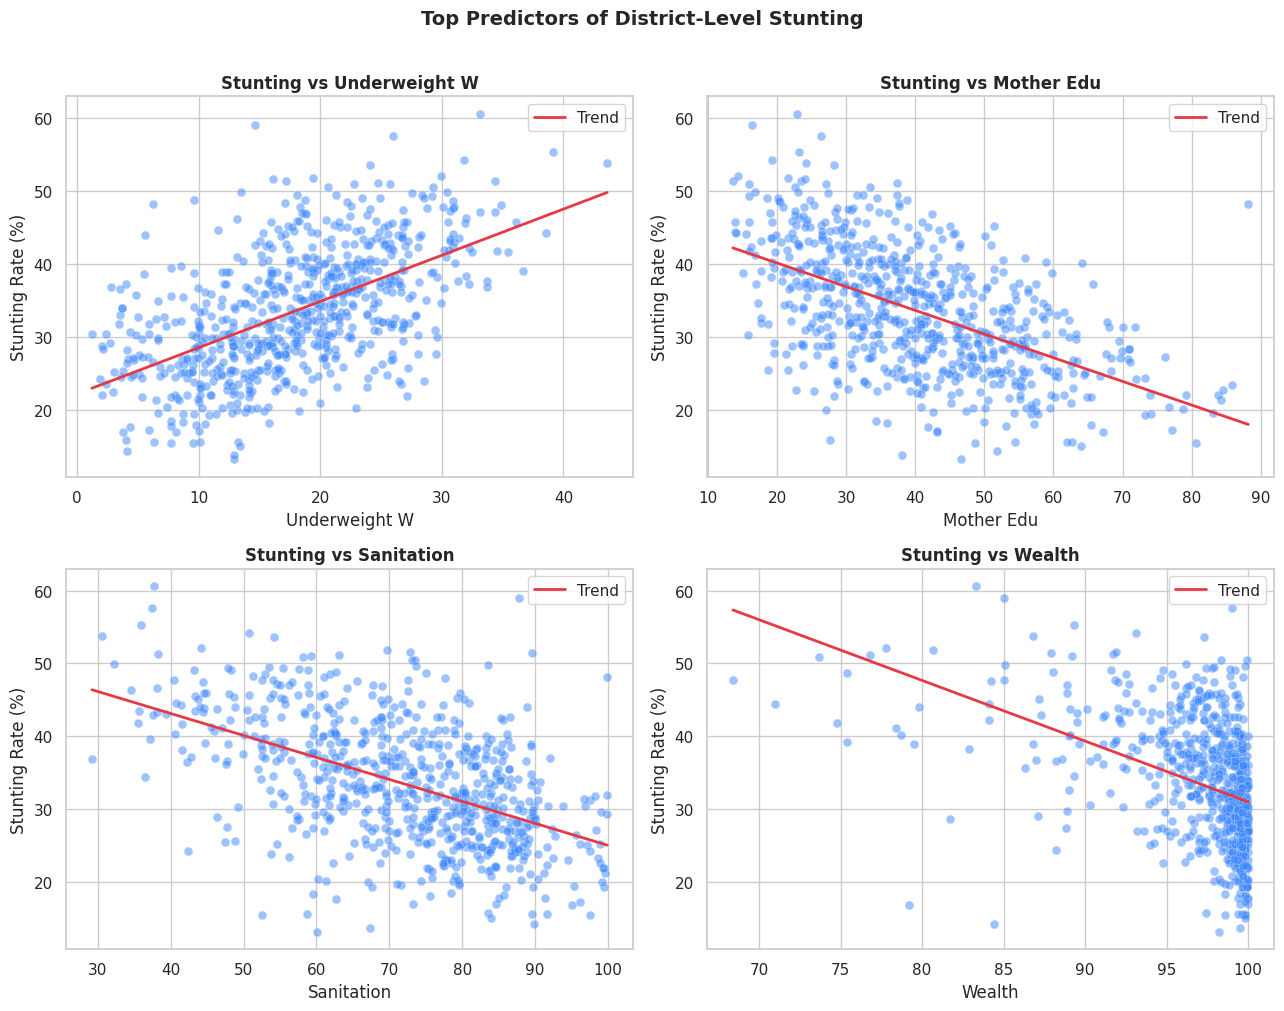

In [12]:
# Pick top 4 correlated features and plot them against stunting
target_corr = df_model.corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top4 = target_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    axes[i].scatter(df_model[feat], df_model[TARGET],
                    alpha=0.5, color='#3a86ff', edgecolors='white', linewidth=0.3, s=40)
    
    # Add trend line
    z = np.polyfit(df_model[feat].dropna(), df_model.loc[df_model[feat].notna(), TARGET], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_model[feat].min(), df_model[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#e63946', linewidth=2, label='Trend')
    
    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('Stunting Rate (%)')
    axes[i].set_title(f'Stunting vs {feat.replace("_"," ").title()}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Top Predictors of District-Level Stunting', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
feat_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feat_cols]
y = df_model[TARGET]

print(f'X: {X.shape} | y: {y.shape}')
print(f'Predicting: district stunting rate (continuous, not binary)')
print(f'Target range: {y.min():.1f}% – {y.max():.1f}%')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler: shifts each feature to mean=0, std=1
# Needed for Ridge regression (linear model is sensitive to scale)
# Random Forest doesn't need it but doesn't hurt
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print(f'\nTrain: {X_train.shape[0]} districts | Test: {X_test.shape[0]} districts')

X: (706, 9) | y: (706,)
Predicting: district stunting rate (continuous, not binary)
Target range: 13.2% – 60.6%

Train: 564 districts | Test: 142 districts


In [14]:
models = {
    'Ridge Regression':      Ridge(alpha=1.0),
    'Random Forest':         RandomForestRegressor(n_estimators=200, max_depth=8,
                                                    min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                        learning_rate=0.05, random_state=42),
}
# Ridge = linear baseline. If RF beats it badly, non-linear patterns exist.
# Random Forest = ensemble of trees. Good with mixed features, robust.
# Gradient Boosting = builds trees sequentially, each fixing previous errors. Often best.

results = {}
for name, model in models.items():
    if 'Ridge' in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'R² Score': r2, 'MAE (%)': mae, 'predictions': y_pred}
    
    print(f'{name:25s}  R²: {r2:.4f}  |  MAE: {mae:.2f}%')

# R² = how much variance the model explains.
# MAE = average error in percentage points.

Ridge Regression           R²: 0.4531  |  MAE: 5.13%
Random Forest              R²: 0.4289  |  MAE: 5.20%
Gradient Boosting          R²: 0.4244  |  MAE: 5.30%


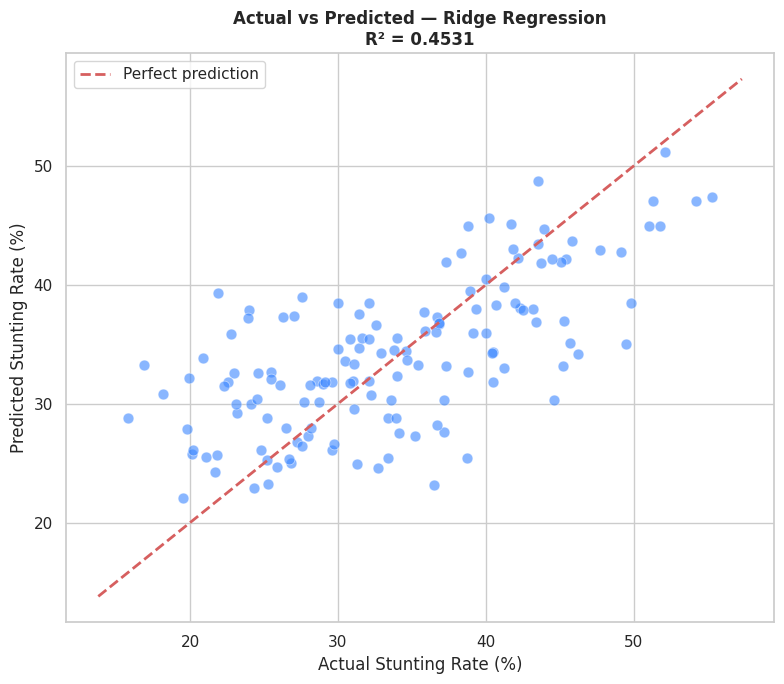

In [15]:
best_model_name = max(results, key=lambda x: results[x]['R² Score'])
best_preds = results[best_model_name]['predictions']

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, best_preds, alpha=0.6, color='#3a86ff', edgecolors='white', linewidth=0.5, s=60)

# Perfect prediction line
lims = [min(y_test.min(), best_preds.min()) - 2,
        max(y_test.max(), best_preds.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Stunting Rate (%)')
ax.set_ylabel('Predicted Stunting Rate (%)')
ax.set_title(f'Actual vs Predicted — {best_model_name}\nR² = {results[best_model_name]["R² Score"]:.4f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot4_actual_vs_pred.png', dpi=150)
plt.show()

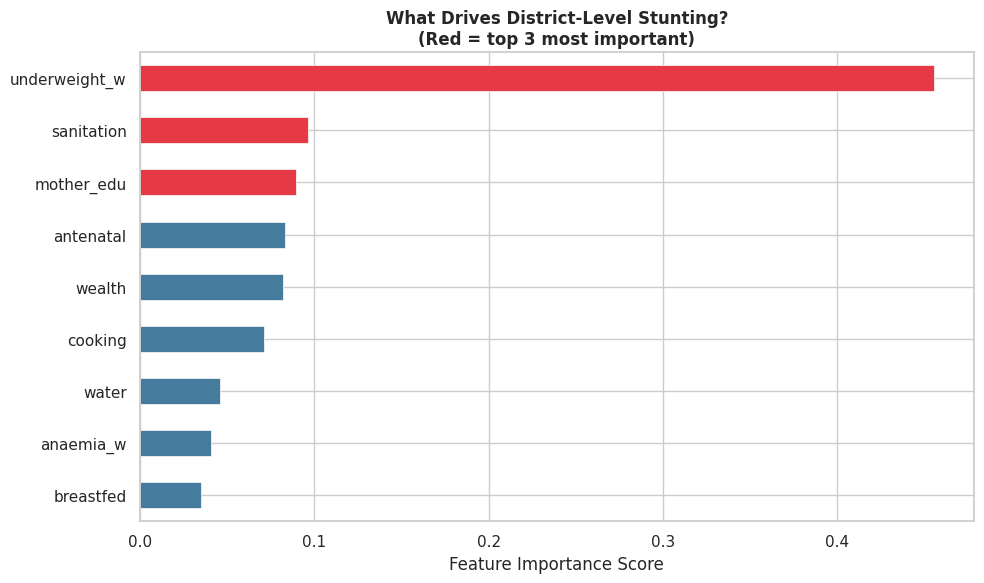

In [16]:
# Use Random Forest for importances
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e63946' if i >= len(importances) - 3 else '#457b9d'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance Score')
ax.set_title('What Drives District-Level Stunting?\n(Red = top 3 most important)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
#we can change these values to get the predicted stunting rate
custom_district = pd.DataFrame([{
    'wealth':       45,   # 45% households with electricity
    'water':        55,   # 55% with clean water
    'sanitation':   40,   # 40% with improved sanitation
    'cooking':      30,   # 30% clean cooking fuel
    'mother_edu':   35,   # 35% women with 10+ years schooling
    'antenatal':    50,   # 50% mothers with 4+ antenatal visits
    'low_bw':       22,   # 22% low birth weight babies
    'breastfed':    55,
    'anaemia_w':    55,   # 55% women anaemic
    'underweight_w': 28,  # 28% women underweight
    'open_defec':   40,   # 40% open defecation
}])

# Keep only features model was trained on
custom_district = custom_district[[c for c in feat_cols if c in custom_district.columns]]
for c in feat_cols:
    if c not in custom_district.columns:
        custom_district[c] = X_train[c].median()
custom_district = custom_district[feat_cols]

predicted_stunting = rf_model.predict(custom_district)[0]

print(f'Predicted stunting rate for this district: {predicted_stunting:.1f}%')
print()
if predicted_stunting > 40:
    print('HIGH priority district — needs immediate intervention')
elif predicted_stunting > 25:
    print('MEDIUM priority — targeted programs recommended')
else:
    print('LOWER risk — monitor and maintain')

Predicted stunting rate for this district: 42.2%

🔴 HIGH priority district — needs immediate intervention


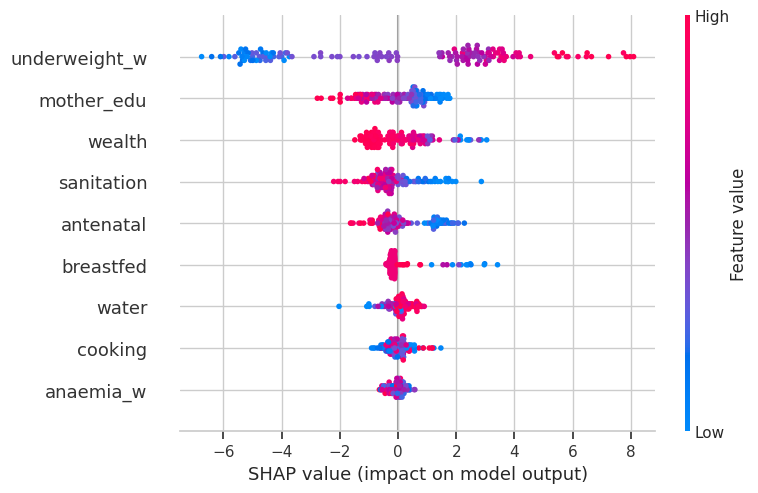

In [18]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [19]:
scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f'CV R²: {scores.mean():.3f} ± {scores.std():.3f}')

CV R²: 0.277 ± 0.158


In [20]:
df['predicted_stunting'] = rf_model.predict(X)
df['priority_tier'] = pd.cut(df['predicted_stunting'],
                              bins=[0,25,40,100],
                              labels=['Low','Medium','High'])
df[['District Names','State/UT','predicted_stunting','priority_tier']]\
  .sort_values('predicted_stunting', ascending=False)\
  .to_csv('district_priority_ranking.csv', index=False)

In [21]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("\nCross Validation Results")

for name, model in models.items():

    if 'Ridge' in name:
        scores = cross_val_score(
            model,
            X_train_sc if False else StandardScaler().fit_transform(X),
            y,
            cv=5,
            scoring='r2'
        )
    else:
        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='r2'
        )

    print(f"{name:25s} CV R²: {scores.mean():.3f} ± {scores.std():.3f}")


Cross Validation Results
Ridge Regression          CV R²: 0.340 ± 0.152
Random Forest             CV R²: 0.277 ± 0.158
Gradient Boosting         CV R²: 0.183 ± 0.213
